In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

<h1>Affichage du jeu de données</h1>

<h2> Analyse </h2>

In [15]:
path = "archive/list_attr_celeba.csv"

df = pd.read_csv(path)

df.describe()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
count,202599.000000,202599.000000,202599.00000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,...,202599.000000,202599.000000,202599.000000,202599.000000,202599.00000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000
mean,-0.777728,-0.466039,0.02501,-0.590857,-0.955113,-0.696849,-0.518408,-0.530935,-0.521498,-0.704016,...,-0.886979,-0.035839,-0.583196,-0.360866,-0.62215,-0.903079,-0.055129,-0.754066,-0.854570,0.547234
std,0.628602,0.884766,0.99969,0.806778,0.296241,0.717219,0.855135,0.847414,0.853255,0.710186,...,0.461811,0.999360,0.812333,0.932620,0.78290,0.429475,0.998482,0.656800,0.519338,0.836982
min,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
50%,-1.000000,-1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
75%,-1.000000,1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,1.000000,-1.000000,1.000000,-1.00000,-1.000000,1.000000,-1.000000,-1.000000,1.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Data columns (total 41 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   image_id             202599 non-null  object
 1   5_o_Clock_Shadow     202599 non-null  int64 
 2   Arched_Eyebrows      202599 non-null  int64 
 3   Attractive           202599 non-null  int64 
 4   Bags_Under_Eyes      202599 non-null  int64 
 5   Bald                 202599 non-null  int64 
 6   Bangs                202599 non-null  int64 
 7   Big_Lips             202599 non-null  int64 
 8   Big_Nose             202599 non-null  int64 
 9   Black_Hair           202599 non-null  int64 
 10  Blond_Hair           202599 non-null  int64 
 11  Blurry               202599 non-null  int64 
 12  Brown_Hair           202599 non-null  int64 
 13  Bushy_Eyebrows       202599 non-null  int64 
 14  Chubby               202599 non-null  int64 
 15  Double_Chin          202599 non-nu

Nombre de classes (attributs binaires) : 40

Distribution par classe (Pourcentage d'images avec l'attribut):
No_Beard               83.493996
Young                  77.361685
Attractive             51.250500
Mouth_Slightly_Open    48.342786
Smiling                48.208037
Wearing_Lipstick       47.243570
High_Cheekbones        45.503186
Male                   41.675428
Heavy_Makeup           38.692195
Wavy_Hair              31.956722
dtype: float64
Goatee         6.276438
Chubby         5.756692
Sideburns      5.651064
Blurry         5.089857
Wearing_Hat    4.846026
Double_Chin    4.668829
Pale_Skin      4.294690
Gray_Hair      4.194986
Mustache       4.154512
Bald           2.244335
dtype: float64


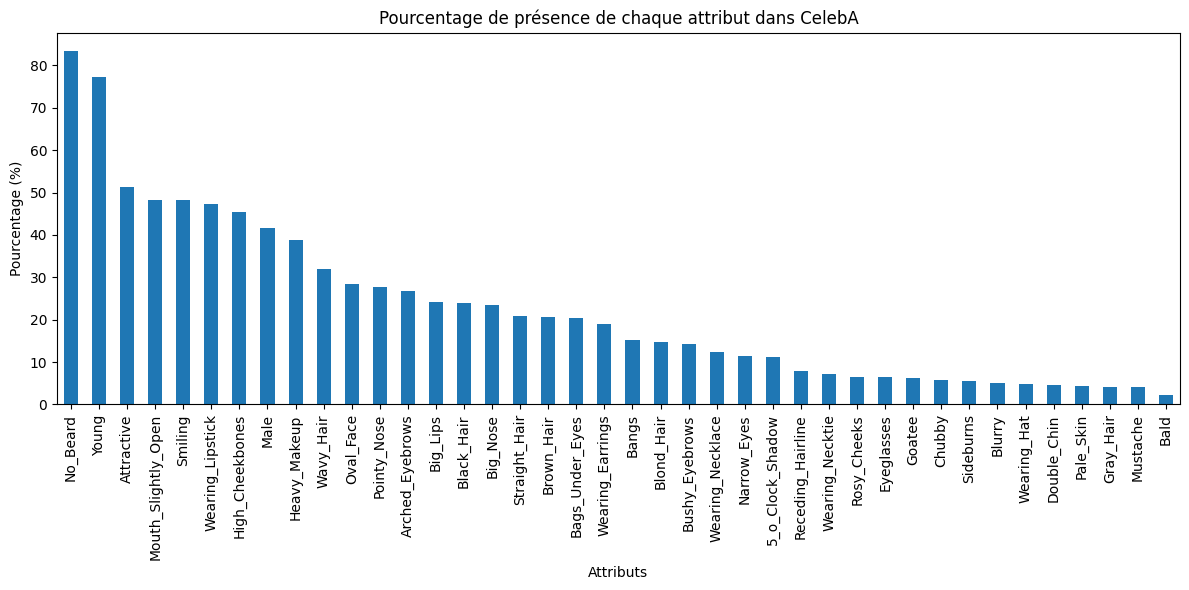

In [21]:
attributs = [col for col in df.columns if col.endswith('.jpg') is False and col != 'image_id']
num_classes = len(num_cols)
print(f"Nombre de classes (attributs binaires) : {num_classes}")

# Distribution des classes
distribution = df[num_cols].apply(lambda x: (x == 1).mean() * 100)
distribution = distribution.sort_values(ascending=False)

print("\nDistribution par classe (Pourcentage d'images avec l'attribut):")
print(distribution.head(10))
print(distribution.tail(10))

plt.figure(figsize=(12, 6))
distribution.plot(kind='bar')
plt.title("Pourcentage de présence de chaque attribut dans CelebA")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Attributs")
plt.tight_layout()
plt.show()

* Le jeu de données se compose de 202 599 images.
* Il existe 40 attributs chacune prenant pour valeur `1` ou `-1`.
* Les classes les plus présentes sont `No_Beard`, `Young`, `Male`, `Attractive`, reflétant le type de personnes surreprésentées.
* La distribution est hétérogène et dèséquilibrée. Beaucoup de classes sont rares (`Bald` < 2.5%, `Mustache`, `Double_Chin`). L'apprentissage d'un modèle pour ces classes sera plus compliqué.

In [4]:
df.isnull().sum()

image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,Blurry,Brown_Hair,Bushy_Eyebrows,Chubby,Double_Chin,Eyeglasses,Goatee,Gray_Hair,Heavy_Makeup,High_Cheekbones,Male,Mouth_Slightly_Open,Mustache,Narrow_Eyes,No_Beard,Oval_Face,Pale_Skin,Pointy_Nose,Receding_Hairline,Rosy_Cheeks,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young    0
dtype: int64

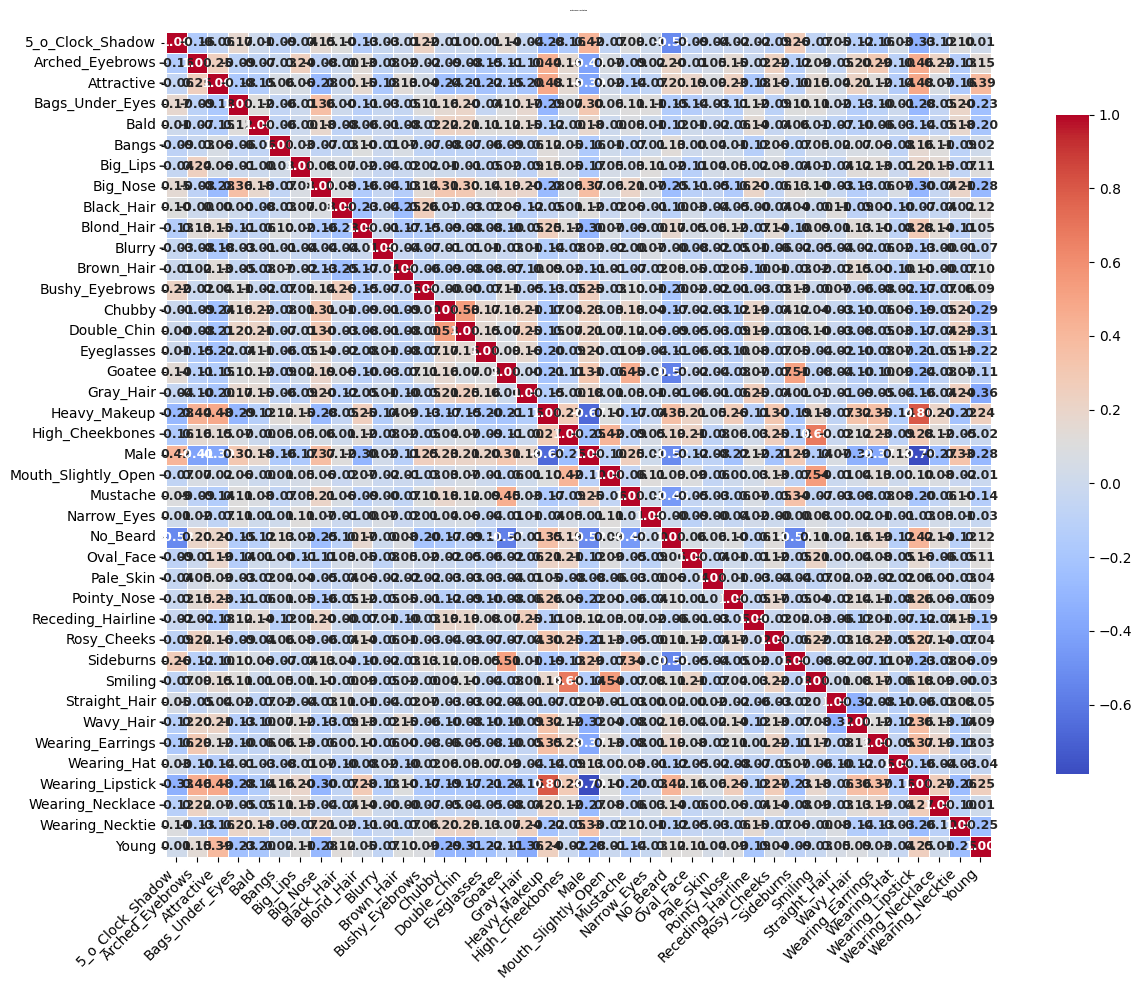

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sb.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot_kws={"size": 9, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8},

)
plt.title("Matrice de corrélation", fontsize=0, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Donc les variables les plus corrélées sont `HeavyMakeup` et `Wearing_Lipstick` ce qui est logique. Ou encore `Chubby` et `double_chin`. 
On peut également constater une corrélation entre `Goatee` et `Mustache` ou encore `Sideburns`, effectivement c'est un look qui se combine régulièrement.

On peut également constater que `Male` est fortement corrélé négativement avec `Wearing_Lipstick` (-0.79) ou encore `Heavy_Makeup` (-0.66).


### 3. Identification des variables sensibles

1. Le Genre `Male` : 
   Un modèle de reconnaissance faciale pourrait présenter des disparités de performance (par exemple, mieux identifier les hommes que les femmes). De plus, l'encodage binaire de CelebA (1 pour `Male`, -1 implicant "Female") invisibilise la non-binarité et fixe une vision stricte du genre.
2. La Couleur de peau `Pale_Skin` :
   L'origine ethnique est une donnée à caractère extrêmement sensible. L'attribut `Pale_Skin` peut également présenter des disparités de performance, de plus qu'il est le seul à aborder la couleur de peau dans ce dataset. Cela peut mener à des algorithmes racistes ou techniquement défaillants selon la carnation.
3. L'Âge `Young` :
   L'âge est un motif de discrimination protégé légalement.
4. Les critères subjectifs et culturels `Attractive` :
   "Être attractif" n'est pas une vérité scientifique, c'est une construction sociale, souvent occidentalo-centrée dans ce genre de dataset. Déterminer "l'attractivité" revient à automatiser un biais cognitif biaisé par les annotateurs initiaux, souvent discriminant.
5. Morphologie `Chubby`, `Double_Chin` :
   Ces attributs sont liés à l'apparence physique, qui peuvent être sujets à des discriminations. 

### 4. Analyse de disparité et Biais du jeu de données

Comme vu dans l'analyse descriptive, les caractéristiques comme `Beard`, `Bald`, `Mustache`, `Chubby` ou `Double_Chin` sont inférieures à 5 %.

Ces biais découlent de la méthode de collecte. **CelebA** signifie "CelebFaces Attributes". Les images proviennent du monde des célébrités (souvent issues du web ou des tapis rouges hollywoodiens). La population mondiale ne ressemble pas à la classe des célébrités. Ces derniers recourent davantage à la chirurgie, au maquillage professionnel, ont des coiffures stéréotypées et une moyenne d'âge ou de corpulence non représentatives de la société civile. Entraîner par exemple une reconnaissance d'humeur (`Smiling`) sur ce set n'aurait pas de sens hors d'un contexte "shooting photo sur tapis rouge".

- Biais d'annotation (subjectivité) : Les attributs comme `Attractive`, `Chubby`, ou `Big_Nose` n'ont aucune objectivité scientifique. Leur présence sous forme de "vérité terrain" binaire dépend entièrement des préjugés, origines et goûts des annotateurs (souvent des travailleurs précaires sur des plateformes de micro-tâches).
- Biais sociétaux : Les attributs imposent une vision normative. Par exemple, comme observé dans notre analyse des corrélations, porter du rouge à lèvres est presque exclusivement corrélé avec le fait de ne pas être un homme (`Male = -1`), renforçant les stéréotypes binaires du genre. Un algorithme entraîné là-dessus associera automatiquement "Maquillage = Femme", fermant la porte à de la nuance.

### 5. Analyse de l'Équité

- Demographic parity : différence absolue de probabilité qu'un événement positif se produise pour le groupe favorisé par rapport au groupe défavorisé. Idéalement, cette valeur doit être de `0`.
- Disparate impact : ratio des probabilités. Souvent, la "règle des 80%" est utilisée en droit indique une discrimination potentielle. Idéalement, le ratio est de `1`.

Nous utiliserons deux attributs sensibles : `Male` et `Pale_Skin`.

In [25]:
sensible_attrs = ['Male', 'Pale_Skin']
dp_results = {'Male': {}, 'Pale_Skin': {}}
di_results = {'Male': {}, 'Pale_Skin': {}}

for S_ in sensible_attrs:
    if S_ not in df.columns:
        continue
    mask_s1 = (df[S_] == 1)
    mask_sm1 = (df[S_] == -1)
    
    Y_cols = [col for col in df.columns if col not in [S_, 'image_id'] and not col.endswith('.jpg')]
    
    for Y_ in Y_cols:
        # P(Y=1 | S=1) : proportion d'individus ayant S=1 qui ont Y=1
        proba_y1_s1 = (df[mask_s1][Y_] == 1).mean()
        # P(Y=1 | S=-1) : proportion d'individus ayant S=-1 qui ont Y=1
        proba_y1_sm1 = (df[mask_sm1][Y_] == 1).mean()
        
        # Demographic Parity: | P(Y=1 | S=1) - P(Y=1 | S=-1) |
        demographic_parity = abs(proba_y1_s1 - proba_y1_sm1)
        # Disparate Impact: P(Y=1 | S=1) / P(Y=1 | S=-1)
        disparate_impact = proba_y1_s1 / proba_y1_sm1 if proba_y1_sm1 > 0 else np.nan
        
        dp_results[S_][Y_] = demographic_parity
        di_results[S_][Y_] = disparate_impact

df_dp = pd.DataFrame(dp_results)
df_di = pd.DataFrame(di_results)

print("Demographic Parity | P(Y=1 | S=1) - P(Y=1 | S=-1)")
display(df_dp.sort_values(by='Pale_Skin', ascending=False).head(10))

print("Disparate Impact P(Y=1 | S=1) / P(Y=1 | S=-1)")
display(df_di.sort_values(by='Pale_Skin', ascending=False).head(10))

print("\n--------------------------------------------------------------")
print("Focus sur S = Pale_Skin et Y = Attractive :")
if 'Attractive' in df_dp.index and 'Pale_Skin' in df_dp.columns:
    print(f"Demographic Parity : {df_dp.loc['Attractive', 'Pale_Skin']:.4f}")
    print(f"Disparate Impact   : {df_di.loc['Attractive', 'Pale_Skin']:.4f}")
print("--------------------------------------------------------------")

Demographic Parity | P(Y=1 | S=1) - P(Y=1 | S=-1)


,Male,Pale_Skin
Attractive,0.399909,0.212156
High_Cheekbones,0.252675,0.199732
Male,NaN,0.188558
Smiling,0.140235,0.174075
Wearing_Lipstick,0.799391,0.159996
Mouth_Slightly_Open,0.100958,0.150745
No_Beard,0.393238,0.112904
Heavy_Makeup,0.658643,0.108966
Big_Nose,0.317357,0.106957
Arched_Eyebrows,0.366107,0.104115


Disparate Impact P(Y=1 | S=1) / P(Y=1 | S=-1)


,Male,Pale_Skin
Blond_Hair,0.086694,1.709334
Bangs,0.409381,1.502731
Attractive,0.411178,1.421452
Arched_Eyebrows,0.127396,1.396616
Big_Lips,0.518001,1.349699
Wearing_Lipstick,0.007689,1.343660
Heavy_Makeup,0.004190,1.285070
Wavy_Hair,0.314894,1.163646
Straight_Hair,1.317138,1.152947
No_Beard,0.606299,1.136014



--------------------------------------------------------------
Focus sur S = Pale_Skin et Y = Attractive :
Demographic Parity : 0.2122
Disparate Impact   : 1.4215
--------------------------------------------------------------


Les calculs révèlent un biais socio-culturel dans les données.

- La parité démographique : Idéalement, la parité est respectée si la différence approche 0. Ici on voit des valeurs qui sont différentes de 0. Par exemple la probabilité d'être étiqueté comme "Attractif" change selon qu'on a la peau claire ou non. On constate également des problèmes de parité sur le genre notamment sur les features concernant le maquillage.
- L'impact disparate : Aux États-Unis, la règle empirique des "4/5e" (ou 80%) stipule qu'un ratio hors de la fourchette [0.8 - 1.25] indique un impact défavorable. On constate ici que le impact est supérieur à 1.25 sur `Pale skin`pour des données naturelles comme les cheveux (blonds, ondulés, straigths) mais aussi sur des données subjectives comme l'attractivité.

Ce biais est l'illustration dd'un prisme occidentalo-centré lors de la collecte ou de l'annotation sous-traitée du jeu de données, l'attribut *Pale Skin* devenant un proxy statistique de l'attribut *Attractive*. 
Entraîner un modèle de machine learning dessus dépendra activament de ce biais...